<a href="https://colab.research.google.com/github/SpoorthiHM022/classroom_behaviour/blob/main/EngXR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q mtcnn tensorflow matplotlib pandas opencv-python

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.7 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
import os
import zipfile
import math
import numpy as np
import pandas as pd
from glob import glob
from mtcnn.mtcnn import MTCNN
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from sklearn.model_selection import train_test_split

In [ ]:
ZIP_PATH = "/content/drive/MyDrive/Student-engagement-dataset.zip"  # upload your zip file to Colab
TARGET_DIR = "/content/Student-engagement-dataset"

if not os.path.exists(TARGET_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall("/content/")
print("Contents:", os.listdir(TARGET_DIR)[:20])

Contents: ['happy', 'Looking Away', 'confused', 'sad']


In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

DATA_DIR = TARGET_DIR
CLASS_NAMES = ['happy', 'Looking Away', 'confused', 'sad']
IMG_SIZE = (224,224)

train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.15,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    label_mode="int",
    class_names=CLASS_NAMES
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.15,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    label_mode="int",
    class_names=CLASS_NAMES
)

print("Detected classes:", CLASS_NAMES)


Found 12837 files belonging to 4 classes.
Using 10912 files for training.
Found 12837 files belonging to 4 classes.
Using 1925 files for validation.
Detected classes: ['happy', 'Looking Away', 'confused', 'sad']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = train_ds.map(normalize_img).cache().shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(normalize_img).cache().prefetch(buffer_size=AUTOTUNE)

print("Train batches:", train_ds)
print("Validation batches:", val_ds)


Train batches: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation batches: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
IMG_SHAPE = (224,224,3)

base = applications.MobileNetV2(input_shape=IMG_SHAPE, include_top=False, pooling='avg', weights='imagenet')
base.trainable = False

inp = layers.Input(shape=IMG_SHAPE)
x = base(inp, training=False)
x = layers.Dropout(0.3)(x)
out = layers.Dense(len(CLASS_NAMES), activation='softmax', name='emotion')(x)

model = models.Model(inputs=inp, outputs=out)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
BATCH = 32
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=BATCH,
    epochs=EPOCHS
)

# Fine-tune base model
base.trainable = True
model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ft_history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=BATCH,
    epochs=5
)


Epoch 1/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 578s 2s/step - accuracy: 0.8027 - loss: 0.4305 - val_accuracy: 0.8062 - val_loss: 0.3958
Epoch 2/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 571s 2s/step - accuracy: 0.8003 - loss: 0.4311 - val_accuracy: 0.8145 - val_loss: 0.3917
Epoch 3/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 567s 2s/step - accuracy: 0.8008 - loss: 0.4212 - val_accuracy: 0.8125 - val_loss: 0.3890
Epoch 4/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 554s 2s/step - accuracy: 0.8043 - loss: 0.4214 - val_accuracy: 0.8166 - val_loss: 0.3931
Epoch 5/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.8004 - loss: 0.4298 - val_accuracy: 0.8078 - val_loss: 0.4227
Epoch 6/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.8012 - loss: 0.4217 - val_accuracy: 0.8239 - val_loss: 0.3998
Epoch 7/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 551s 2s/step - accuracy: 0.8009 - loss: 0.4357 - val_accuracy: 0.7969 - val_loss: 0.4104
Epoch 8/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 556s 2s/step - accuracy: 0.8071 - loss: 0.4280 - val_accu

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/student_engagement_classifier.h5"
model.save(MODEL_PATH)
print("✅ Model saved at:", MODEL_PATH)


NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras.models import load_model
MODEL_PATH = "/content/drive/MyDrive/student_engagement_classifier.h5"
model = load_model(MODEL_PATH)
print("✅ Model loaded from Drive")


✅ Model loaded from Drive


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


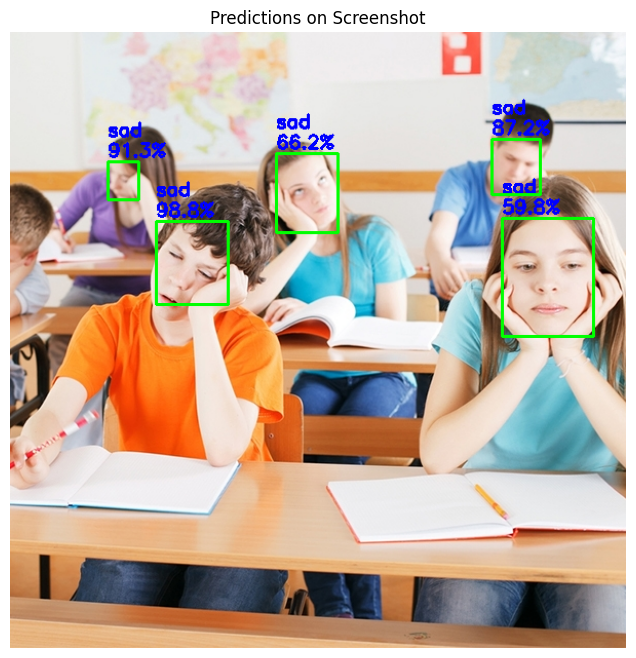

In [ ]:
detector = MTCNN()

# Change this path to your uploaded screenshot
img_path = "/content/students_looking_bored_in_class.jpg"
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

dets = detector.detect_faces(img_rgb)
annotated = img_rgb.copy()

for d in dets:
    x, y, w, h = d['box']
    face = img_rgb[y:y+h, x:x+w]
    try:
        face_resized = cv2.resize(face, (224,224)) / 255.0
    except:
        continue
    face_input = np.expand_dims(face_resized.astype(np.float32), 0)
    preds = model.predict(face_input)
    pred_idx = np.argmax(preds[0])
    label = CLASS_NAMES[pred_idx]
    conf = preds[0][pred_idx] * 100

    cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(annotated, label, (x, y-25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)
    cv2.putText(annotated, f"{conf:.1f}%", (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

plt.figure(figsize=(10,8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Predictions on Screenshot")
plt.show()
